# Plotting using the Mapping API

`Mapping` uses the algorithms outlined in [**Algorithms useful for calculating multi-component equilibria, phase diagrams and other kinds of diagrams** (B. Sundman, N. Dupin, B. Hallstedt, Calphad 75 (2021) 102330)](https://doi.org/10.1016/j.calphad.2021.102330) to construct phase diagrams by stepping along phase boundaries.

`binplot` and `ternplot` are thin wrappers around the binary and ternary mapping strategies; however, additional plotting capabilities are available through the `mapping` module.

## Binary phase diagrams with mapping

This shows how to plot a binary phase diagram through mapping as an alternative to binplot.

C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\4137447221.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


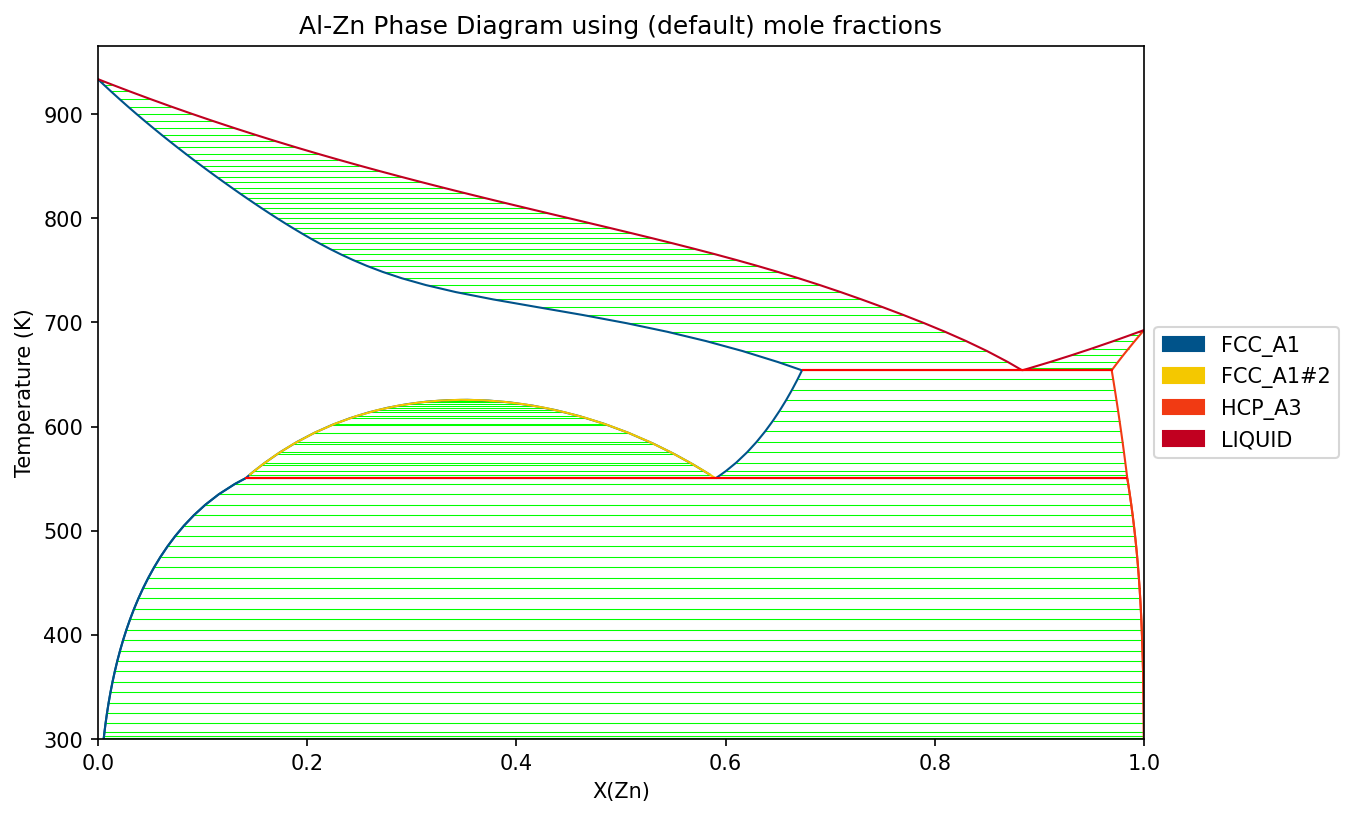

In [1]:
from pycalphad import Database, variables as v
from pycalphad.mapping import BinaryStrategy, plot_binary
import matplotlib.pyplot as plt

dbf = Database('alzn_mey.tdb')
comps = ['AL', 'ZN', 'VA']
conds = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('ZN'):(0, 1, 0.02)}

# Phases will be automatically filtered with components if no phases are passed
binary = BinaryStrategy(dbf, comps, phases=None, conditions=conds)
binary.do_map()
ax = plot_binary(binary)
fig = ax.figure
ax.set_title("Al-Zn Phase Diagram using (default) mole fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
fig.show()

C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\3029474166.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


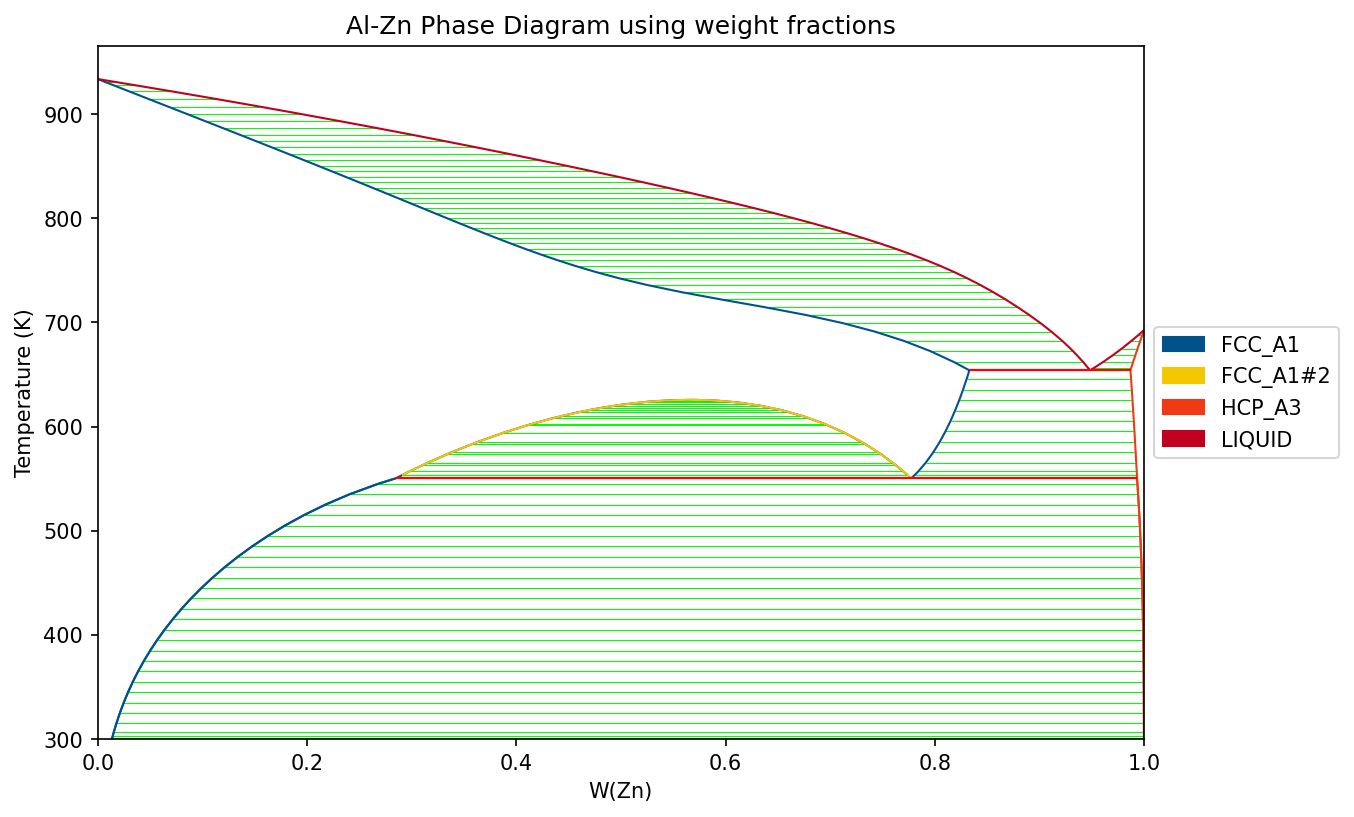

In [2]:
# Plotting in weight fraction
ax = plot_binary(binary, v.W('ZN'), v.T)
fig = ax.figure
ax.set_xlim([0, 1])
ax.set_title("Al-Zn Phase Diagram using weight fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
fig.show()

Similarly, the same can be done for ternaries using TernaryStrategy and plot_ternary.

## Step plotting

Step mapping allows computing equilibrium along a single axis. By default, step plotting will plot phase fraction vs. variable axis, but this can be modified through plotting.

C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\2676399610.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


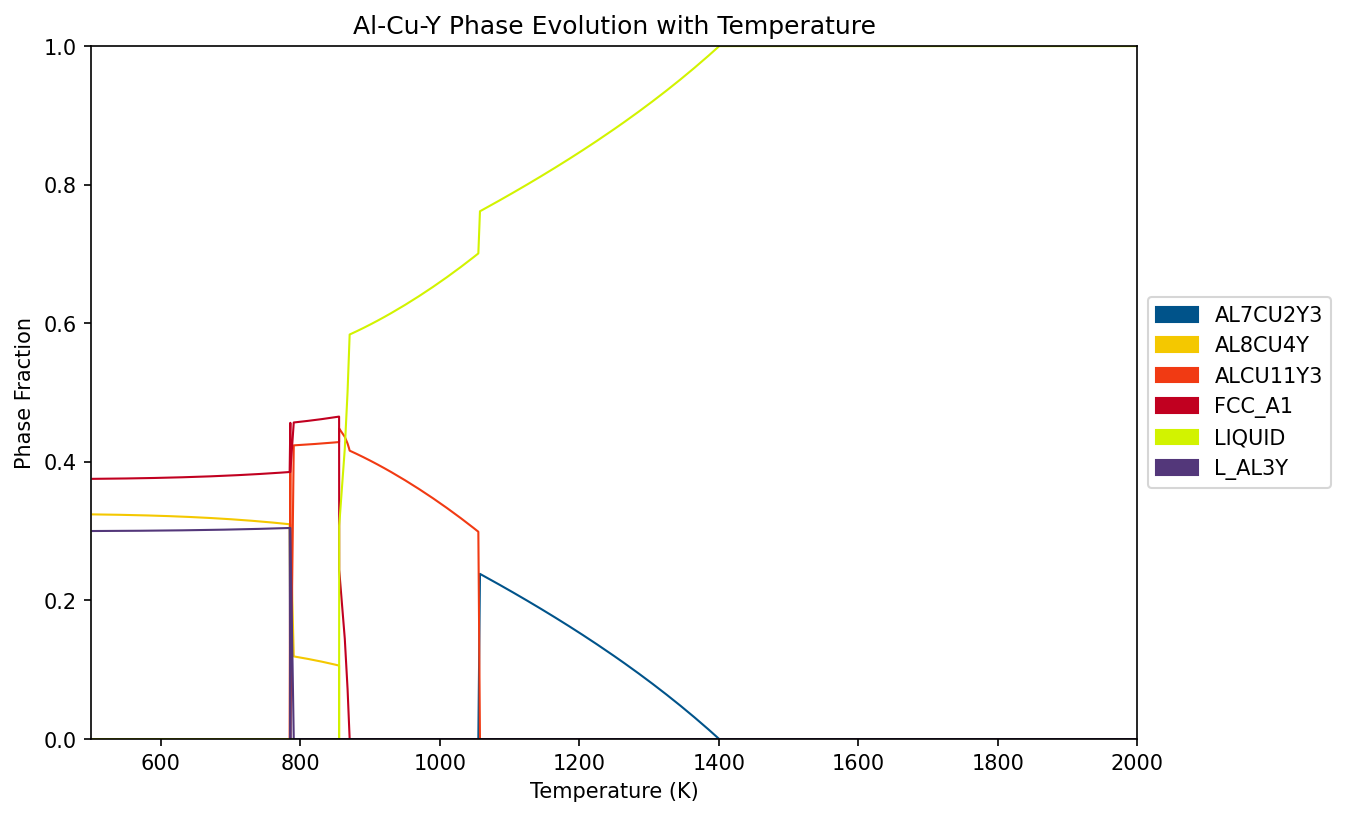

In [3]:
from pycalphad.mapping import StepStrategy, plot_step

dbf = Database('Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (500, 2000, 10), v.X('AL'): 0.8, v.X('CU'): 0.1, v.P: 101325, v.N: 1}

step = StepStrategy(dbf, comps, phases=None, conditions=conds)
step.do_map()

ax = plot_step(step)
fig = ax.figure
ax.set_title("Al-Cu-Y Phase Evolution with Temperature")
ax.set_xlim(500, 2000)
fig.set_size_inches(9, 6)
fig.set_dpi(150)
fig.show()

C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\153552101.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


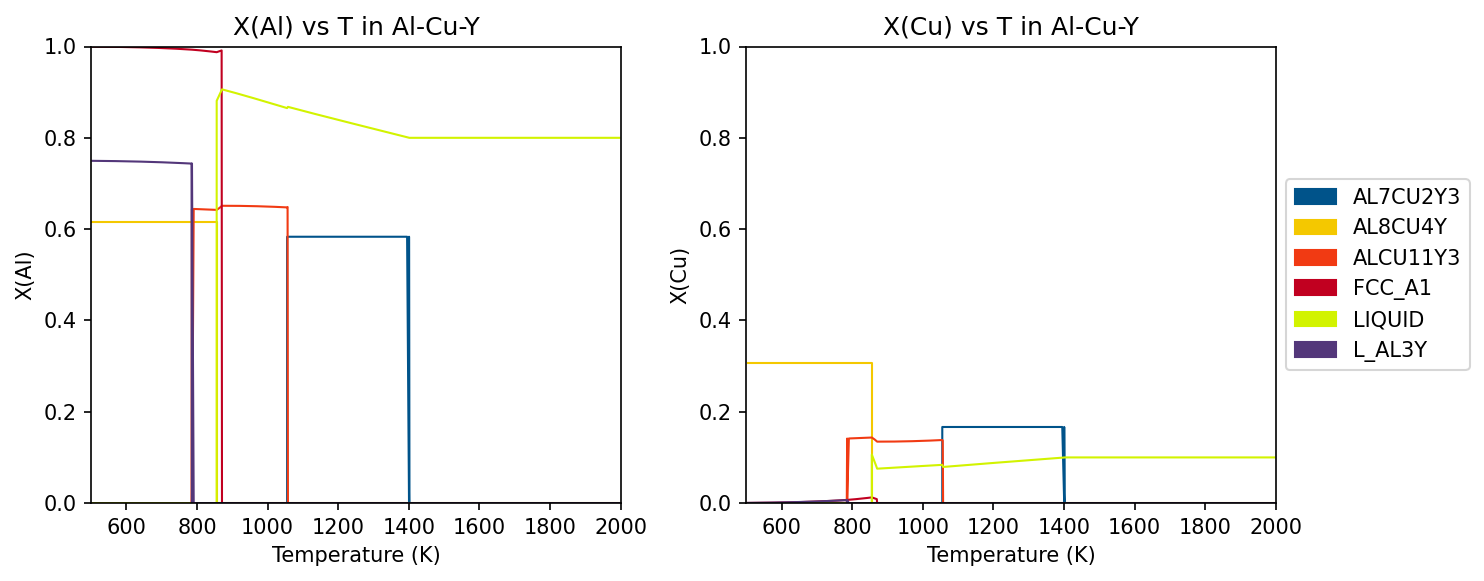

In [4]:
# Plotting composition of Al and Cu in each phase
fig, ax = plt.subplots(1, 2, figsize=(10,4))
plot_step(step, x=v.T, y=v.X('AL'), ax=ax[0])
plot_step(step, x=v.T, y=v.X('CU'), ax=ax[1])

ax[0].set_title("X(Al) vs T in Al-Cu-Y")
ax[0].set_xlim([500, 2000])
ax[0].set_ylim([0, 1])
ax[0].get_legend().remove()

ax[1].set_title("X(Cu) vs T in Al-Cu-Y")
ax[1].set_xlim([500, 2000])
ax[1].set_ylim([0, 1])
fig.tight_layout()
fig.set_dpi(150)
fig.show()

C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\1619890118.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


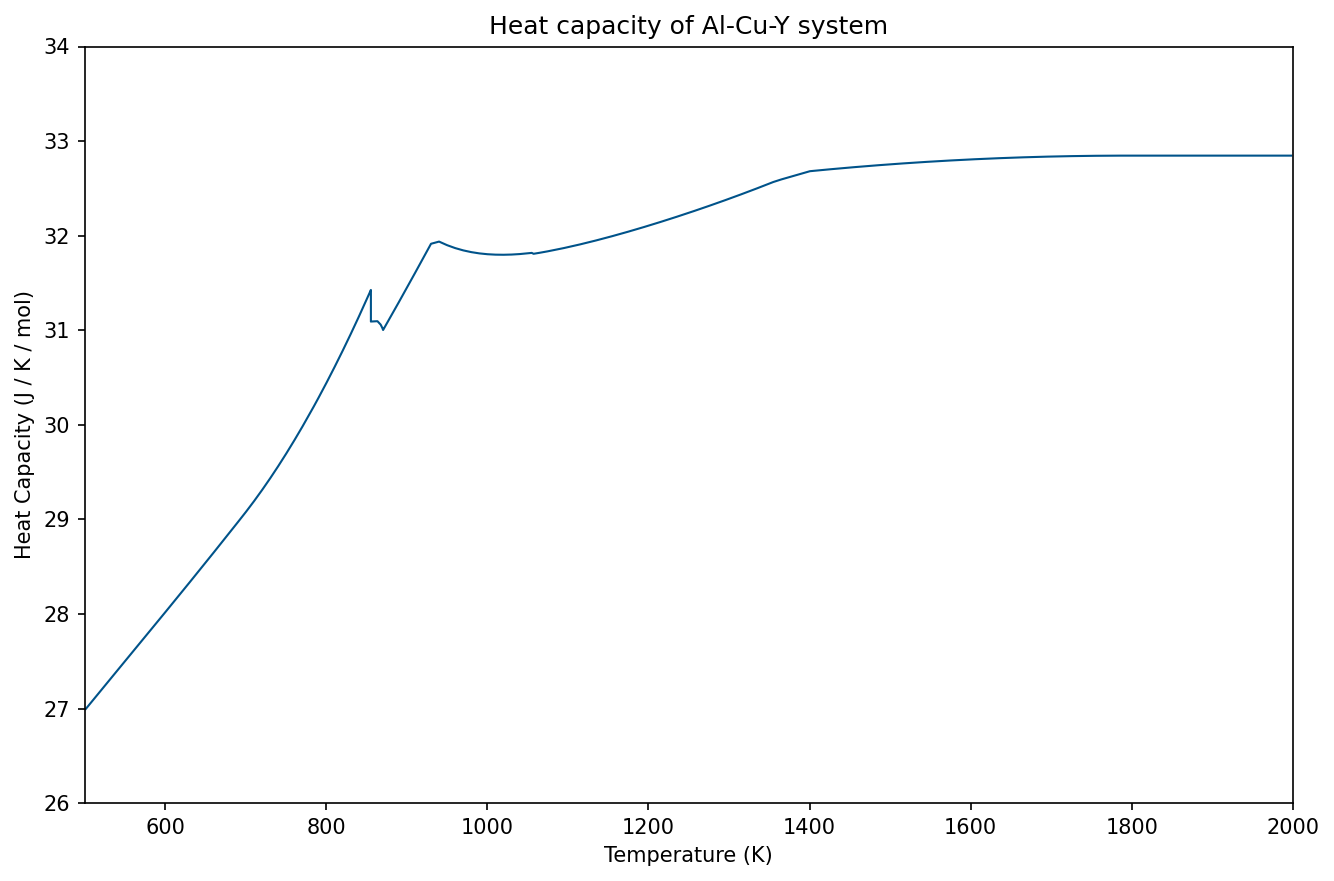

In [5]:
# Plotting heat capacity vs T
fig, ax = plt.subplots(figsize=(9,6))
plot_step(step, x=v.T, y='CPM', ax=ax)
ax.set_title("Heat capacity of Al-Cu-Y system")
ax.set_xlim([500, 2000])
ax.set_ylim([26, 34])
fig.tight_layout()

fig.set_dpi(150)
fig.show()

## Isopleth plotting

For multicomponent systems, isopleths can be computed and plotted.

C:\Users\ury3\Documents\codes\pycalphad\pycalphad\core\conditions.py:116: UserWarning: Some specified compositions are below the minimum allowed composition of 1e-10.
  warnings.warn(
C:\Users\ury3\AppData\Local\Temp\ipykernel_34600\3216063920.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


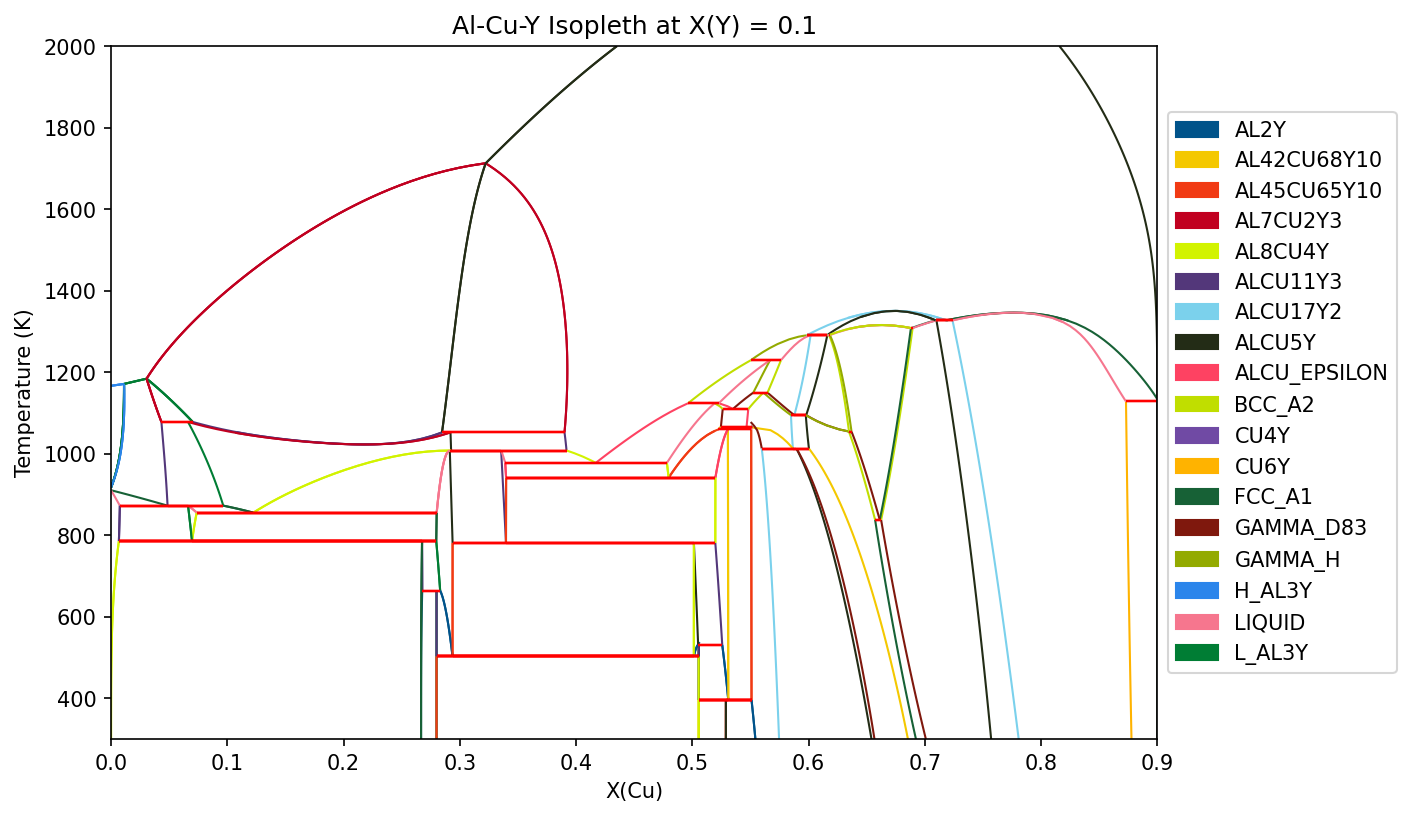

In [6]:
from pycalphad.mapping import IsoplethStrategy, plot_isopleth

dbf = Database('Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (300, 2000, 10), v.P: 101325, v.N: 1, v.X('Y'): 0.1, v.X('CU'): (0, 1, 0.01)}

iso = IsoplethStrategy(dbf, comps, phases=None, conditions=conds)
iso.do_map()
ax = plot_isopleth(iso)
fig = ax.figure
ax.set_title("Al-Cu-Y Isopleth at X(Y) = 0.1")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
fig.show()